# DQN Training Results

Connect to Google Colab CPU or directly login in the browser.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 · Load training logs

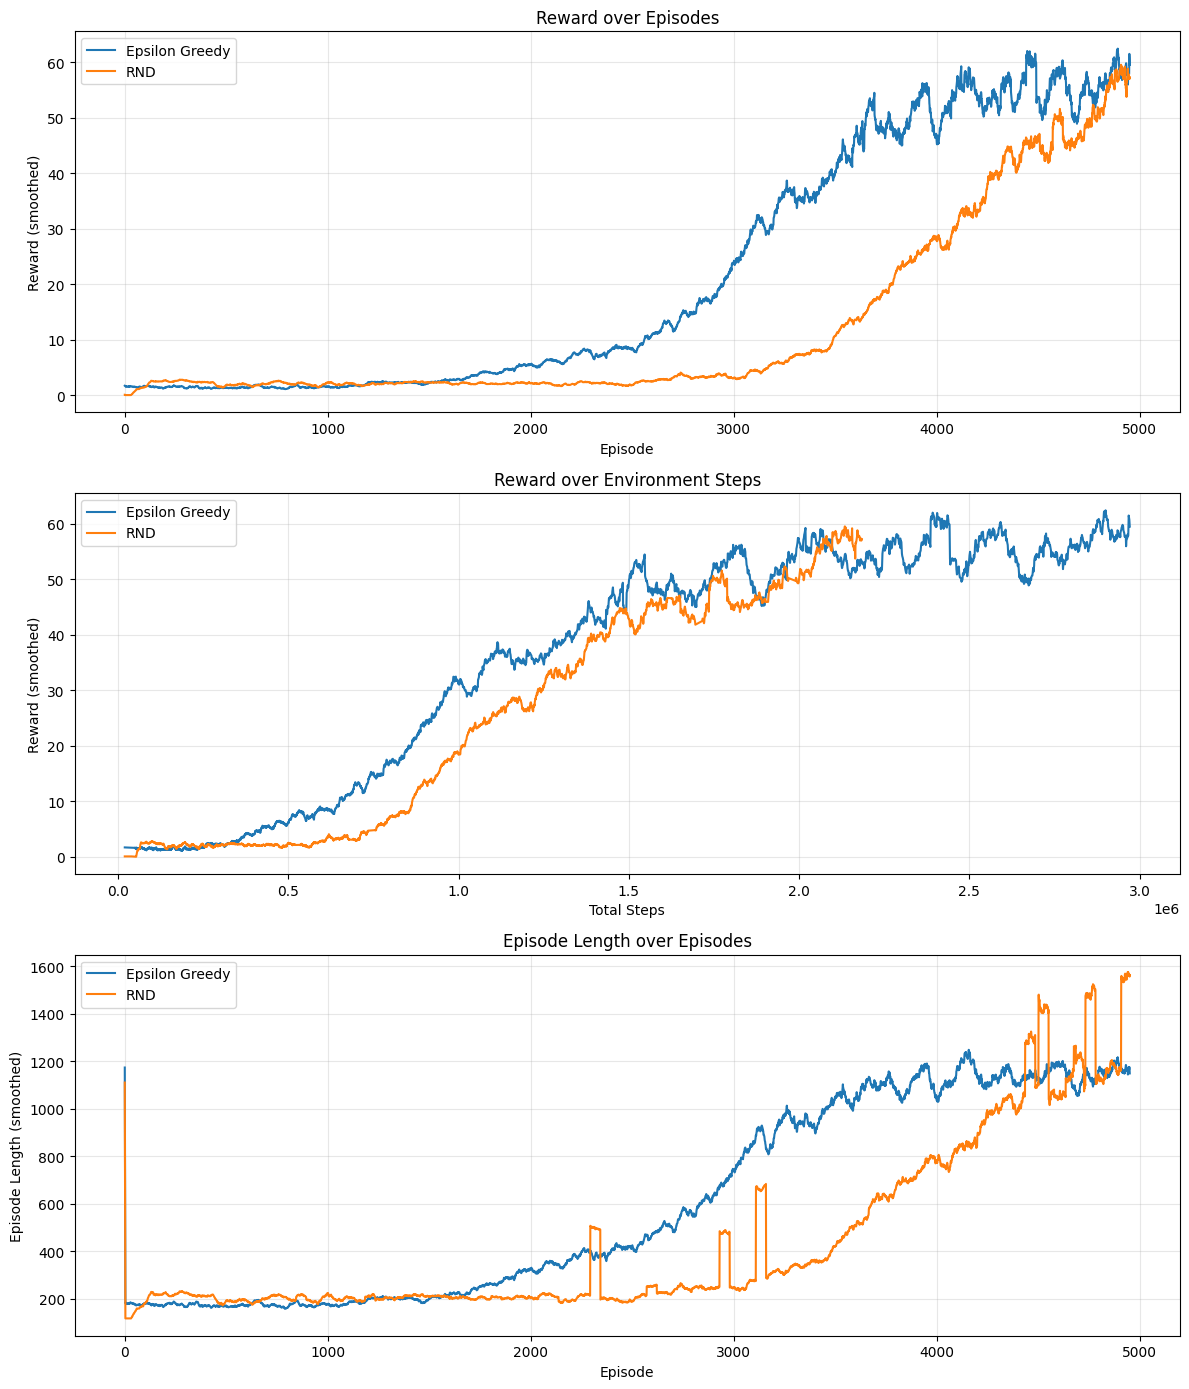

In [2]:
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np

EPSILON_GREEDY_DIR = '/content/drive/MyDrive/Exploration/EpsilonGreedy/'
BOLTZMANN_DIR      = '/content/drive/MyDrive/Exploration/Boltzmann/'
RND_DIR            = '/content/drive/MyDrive/Exploration/RND/'

experiments = [
    ("Epsilon Greedy", EPSILON_GREEDY_DIR),
    ("Boltzmann", BOLTZMANN_DIR),
    ("RND", RND_DIR),
]

def load_log(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))

    episodes    = np.array([r["episode"]     for r in records])
    total_steps = np.array([r["total_steps"] for r in records])
    rewards     = np.array([r["reward"]      for r in records])
    ep_lens     = np.array([r["ep_len"]      for r in records])

    return episodes, total_steps, rewards, ep_lens


def smooth(values, window=50):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def align_and_stack(list_of_arrays):
    """Trim all arrays to shortest length and stack"""
    min_len = min(len(arr) for arr in list_of_arrays)
    return np.stack([arr[:min_len] for arr in list_of_arrays])

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
ax_rew_ep, ax_rew_step, ax_len_ep = axes

for label, directory in experiments:
    log_files = sorted(glob.glob(os.path.join(directory, '*.jsonl')))

    all_rewards = []
    all_ep_lens = []
    all_steps   = []
    all_episodes = None

    for path in log_files:
        episodes, total_steps, rewards, ep_lens = load_log(path)

        s_rewards = smooth(rewards)
        s_ep_lens = smooth(ep_lens)

        ep_trim   = episodes[:len(s_rewards)]
        step_trim = total_steps[:len(s_rewards)]

        all_rewards.append(s_rewards)
        all_ep_lens.append(s_ep_lens)
        all_steps.append(step_trim)

        if all_episodes is None:
            all_episodes = ep_trim[:len(s_rewards)]

    if len(all_rewards) == 0:
        continue

    # Stack runs
    rewards_stack = align_and_stack(all_rewards)
    ep_lens_stack = align_and_stack(all_ep_lens)
    steps_stack   = align_and_stack(all_steps)

    # Mean + std
    rew_mean = rewards_stack.mean(axis=0)
    rew_std  = rewards_stack.std(axis=0)

    len_mean = ep_lens_stack.mean(axis=0)
    len_std  = ep_lens_stack.std(axis=0)

    steps_mean = steps_stack.mean(axis=0)

    # Reward vs Episodes
    ax_rew_ep.plot(all_episodes[:len(rew_mean)], rew_mean, label=label)
    ax_rew_ep.fill_between(
        all_episodes[:len(rew_mean)],
        rew_mean - rew_std,
        rew_mean + rew_std,
        alpha=0.2
    )

    # Reward vs Steps
    ax_rew_step.plot(steps_mean, rew_mean, label=label)
    ax_rew_step.fill_between(
        steps_mean,
        rew_mean - rew_std,
        rew_mean + rew_std,
        alpha=0.2
    )

    # Episode Length vs Episodes
    ax_len_ep.plot(all_episodes[:len(len_mean)], len_mean, label=label)
    ax_len_ep.fill_between(
        all_episodes[:len(len_mean)],
        len_mean - len_std,
        len_mean + len_std,
        alpha=0.2
    )

ax_rew_ep.set_title("Reward over Episodes")
ax_rew_ep.set_xlabel("Episode")
ax_rew_ep.set_ylabel("Reward (smoothed)")
ax_rew_ep.grid(True, alpha=0.3)

ax_rew_step.set_title("Reward over Environment Steps")
ax_rew_step.set_xlabel("Total Steps")
ax_rew_step.set_ylabel("Reward (smoothed)")
ax_rew_step.grid(True, alpha=0.3)

ax_len_ep.set_title("Episode Length over Episodes")
ax_len_ep.set_xlabel("Episode")
ax_len_ep.set_ylabel("Episode Length (smoothed)")
ax_len_ep.grid(True, alpha=0.3)

# Clean legends
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()